In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *
from pklib.rl import *




## SARSA + >Decision Tree Q-Approximator

In [2]:

def remove_highly_correlated_features(df, threshold=0.9):
    """
    Find features with correlation above a threshold and remove them from the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The original DataFrame.
    threshold (float): The correlation threshold. Features with correlation above this will be removed.
    
    Returns:
    pd.DataFrame: The DataFrame with highly correlated features removed.
    list: List of removed features.
    """
    # Calculate the correlation matrix
    correlation_matrix = df.corr().abs()  # Use absolute correlation values for thresholding
    
    # Create a boolean mask for correlations above the threshold
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    
    # Identify features with correlation greater than the threshold
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    
    # Remove the highly correlated features from the DataFrame
    df_reduced = df.drop(columns=to_drop)
    
    return df_reduced, to_drop


# df_reduced, to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# len(to_drop), df_reduced.columns

In [3]:
def load_and_create_features(exchange, asset, quote, nhours, train_size=0.7):
    """
    Load the data, create technical indicators, and return feature DataFrames with a train-test split.

    Parameters:
    exchange (str): Exchange name (e.g., 'binance').
    asset (str): Asset symbol (e.g., 'BTC').
    quote (str): Quote currency (e.g., 'USDT').
    nhours (int): Number of hours for the timeframe (e.g., 8 for 8-hour candles).
    train_size (float): Proportion of the data to use for training (default is 0.7).

    Returns:
    tuple: (train_df, test_df, train_log_prices, test_log_prices) DataFrames for training and testing.
    """

    timeframe = f'{nhours}h'

    # Load candle data
    df = load_candles(exchange, asset, quote, timeframe)

    # Define Ichimoku Cloud parameters and scale them based on the timeframe
    params = {'conversion_periods': 30, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 30}
    params = {k: int(v * (24/nhours)) for k, v in params.items()}

    # Calculate moving average periods
    # d50_period = 50 * int(24/nhours)
    d100_period = 100 * int(24/nhours)
    d150_period = int(1.5 * d100_period)
    d50_period = int(5 * d100_period)

    # Create indicators and features
    df_indicators = ichimoku_cloud_indicator(df, **params
        ).join(df[['high', 'low', 'close', 'open']]
        ).join(create_moving_average_features(
            df, ema_periods=[7, 14, 21, 50, 100, d50_period, d100_period, d150_period],
            sma_periods=[7, 14, 21, 50, 100, d50_period, d100_period, d150_period]
        )).dropna()

    # Define column comparisons for features
    compare_columns = [
        ('tenkan', 'kijun', 'close'), 
        ('kumo_upper', 'close'), 
        ('lead_span_A', 'lead_span_B', 'close'),
        # ('close', f'sma_{d50_period}'),
        # ('close', f'sma_{d100_period}'),
        # ('close', f'sma_{d150_period}'),
        # ('close', f'ema_{d100_period}'),
        # (f'sma_{d50_period}', f'sma_{d100_period}'),
        # (f'sma_{d150_period}', f'sma_{d100_period}'),
        # (f'ema_{d100_period}', f'sma_{d100_period}'),
        # (f'ema_{d50_period}', f'sma_{d100_period}'),
        # (f'ema_{d150_period}', f'sma_{d150_period}')
    ]

    # Create comparison features
    df_comp_features = create_comparison_features(df_indicators, compare_columns).dropna()

    # Apply logarithmic transformation to prices
    log_prices = df['close'].apply(np.log)[df_comp_features.index]

    # Perform the train-test split
    train_df, test_df, train_log_prices, test_log_prices = train_test_split(df_comp_features, log_prices, train_size)

    return train_df, test_df, train_log_prices, test_log_prices


# df_comp_features = create_comparison_features(df_indicators, compare_columns)
# # percent_diff_thresholds = [-10, -5,-3,-1, 0, 2, 5, 10]
# # df_percent_diffs = create_signed_difference_features_multi(df_indicators,[
# #             ('close', 'tenkan', percent_diff_thresholds),
# #             ('close', 'kijun', percent_diff_thresholds),
# #             ('tenkan', 'kijun', percent_diff_thresholds),
# #             # ('close', 'ema_21', percent_diff_thresholds),
# #             # ('close', 'ema_14', percent_diff_thresholds),
# #             # ('close', 'ema_7', percent_diff_thresholds),
# #             # ('ema_7', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'ema_21', percent_diff_thresholds),
# #             # ('ema_21', 'ema_50', percent_diff_thresholds),
# #             # ('ema_7', 'ema_21', percent_diff_thresholds),
# #         ])


# # df_percent_diffs, _ = remove_highly_correlated_features(df_percent_diffs, threshold=0.7)

# df_features = df_comp_features#.join(df_percent_diffs).dropna()
# # df_features, features_to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# # print(f'features_to_drop:')
# # pprint(features_to_drop)


TRAINING	 nhours=4	num_steps=430.00K,	 lookback_window_size=12
Step: 10126, # Positions: 1258, Cumulative PnL%: 61.02
Episode Steps: 10114, Global Steps: 10114, Cumulative PnL(log): 0.48, Epsilon: 0.5000
Step: 10126, # Positions: 1297, Cumulative PnL%: 87.79
Episode Steps: 10114, Global Steps: 20228, Cumulative PnL(log): 0.63, Epsilon: 0.5000
Step: 10126, # Positions: 1318, Cumulative PnL%: -42.21
Episode Steps: 10114, Global Steps: 30342, Cumulative PnL(log): -0.55, Epsilon: 0.5000
Step: 10126, # Positions: 1354, Cumulative PnL%: 17.30
Episode Steps: 10114, Global Steps: 40456, Cumulative PnL(log): 0.16, Epsilon: 0.5000
Step: 10126, # Positions: 1340, Cumulative PnL%: 23.03
Episode Steps: 10114, Global Steps: 50570, Cumulative PnL(log): 0.21, Epsilon: 0.5000
Step: 10126, # Positions: 1361, Cumulative PnL%: 51.43
Episode Steps: 10114, Global Steps: 60684, Cumulative PnL(log): 0.41, Epsilon: 0.5000
Step: 10126, # Positions: 1398, Cumulative PnL%: -21.26
Episode Steps: 10114, Global Step

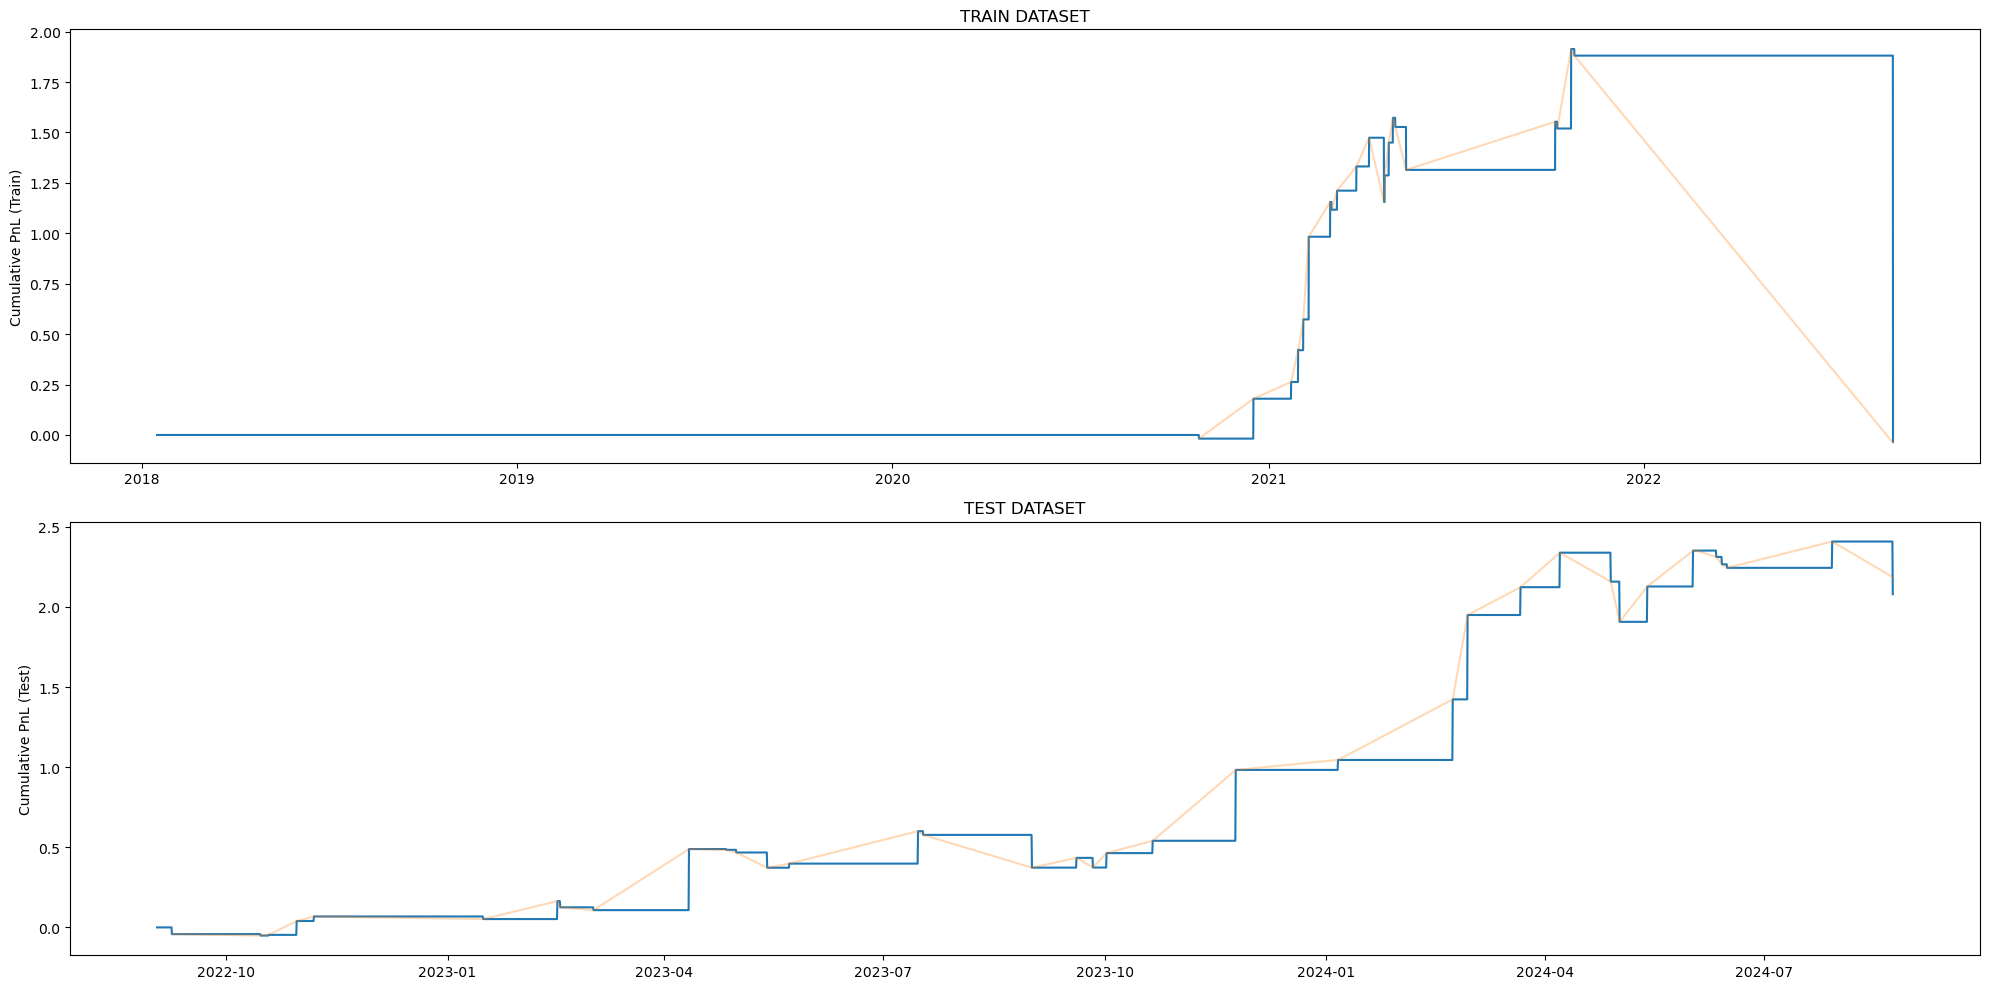

In [4]:
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 4

lookback_window_size = int(24/nhours) * 7
# Load data and create features
train_df, test_df, train_log_prices, test_log_prices = load_and_create_features(exchange, asset, quote, nhours,train_size=0.7)


# Initialize the training and testing environments
train_env = TradingEnv(train_df, train_log_prices, lookback_window_size=lookback_window_size)
test_env = TradingEnv(test_df, test_log_prices, lookback_window_size=lookback_window_size)

# Initialize the SARSA agent with overfitting prevention
# agent = SARSATabularAgent(env=train_env)
# agent = SARSAOptTabularAgent(env=train_env, epsilon=.5, alpha=0.3, gamma=0.99, min_epsilon=0.001, epsilon_decay=0.9995, early_stopping_steps=1000000)
agent = SARSAOptTabularAgent(train_env, alpha=0.3, epsilon=0.5, gamma=0.99, early_stopping_steps=1000000)


# Train the agent using SARSA
# num_episodes= int((5000*train_env.observation_space.shape[0]) / len(train_df)) 

num_steps= int((5000*train_env.observation_space.shape[0]))

# print(f'TRAINING\t nhours={nhours}\tnum_episodes={num_episodes},\t lookback_window_size={lookback_window_size}')
print(f'TRAINING\t nhours={nhours}\tnum_steps={num_steps/1000:.2f}K,\t lookback_window_size={lookback_window_size}')
agent.train(num_steps=num_steps)

# with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)
# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)


train_backtest_df,train_trades_df = perform_backtest(agent, train_env)
test_backtest_df,test_trades_df = perform_backtest(agent, test_env)

plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)
# # with open('complex_object.pkl', 'rb') as f: env = pickle.load(f)

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)

In [ ]:
# train_trades_df
train_df

In [ ]:

# Create a single figure with two separate axes (not sharing x-axis)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

# Plot for the training dataset
ax1.plot(train_backtest_df.cumulative_pnl.apply(np.expm1)) #.plot(ax=ax1, title='TRAIN DATASET')
ax1.plot(train_trades_df.exit_index,train_trades_df.pnl.cumsum().apply(np.expm1))
ax1.set_ylabel('Cumulative PnL (Train)')

# # # Plot for the training dataset
ax2.plot(test_backtest_df.cumulative_pnl.apply(np.expm1)) #.plot(ax=ax1, title='TRAIN DATASET')
ax2.plot(test_trades_df.exit_index,test_trades_df.pnl.cumsum().apply(np.expm1))
ax2.set_ylabel('Cumulative PnL (Test)')

# Display the figure
plt.tight_layout()
plt.show()

In [ ]:
train_trades_df

In [ ]:

exchange = 'binance';asset = 'AVAX';quote = 'USDT';nhours = 4

# Load data and create features
train_df, test_df, train_log_prices, test_log_prices = load_and_create_features(exchange, asset, quote, nhours, train_size=0)

train_env = TradingEnv(train_df, train_log_prices, lookback_window_size=10)
test_env = TradingEnv(test_df, test_log_prices, lookback_window_size=10)
test_backtest_df, trades = perform_backtest(agent, test_env)
trades
# trades_df['entry_index'] = test_env.logprice.index[trades_df.entry_step]
# trades_df['exit_index'] = test_env.logprice.index[trades_df.exit_step]
# trades_df['entry_logprice'] = test_env.logprice.iloc[trades_df.entry_step]
# trades_df['exit_logprice'] = test_env.logprice.iloc[trades_df.exit_step]

# trades_df['pnl'] = trades_df['exit_logprice'] - trades_df['entry_logprice']
# trades_df.set_index('exit_index')
# ax1 = test_backtest_df.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET');
# test_trades_df.pnl.cumsum().apply(np.expm1).plot(ax=ax1)
# plt.show();


In [ ]:
test_trades_df

In [ ]:

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)
# with open('SARSA-Agent.pkl', 'rb') as f: agent = pickle.load(f)

# lookback_window_size = 4
exchange, asset, quote, timeframe = 'binance', 'BTC', 'USDT', '1h'
df = load_candles(exchange,asset, quote, timeframe)['2022-11':]#.iloc[-35000:-5000]
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# params = {'conversion_periods':30, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
df_indicators = ichimoku_cloud_indicator(df, **params
    ).join(df[['high','low','close','open']]
    ).join(create_moving_average_features(df, ema_periods=[5,9,14,21,50,120], sma_periods=[5,9,14,21,50,120])
    ).dropna()
df_comp_features = create_comparison_features(df_indicators, compare_columns).dropna()
test_env = TradingEnv(df_comp_features, log_prices, lookback_window_size=lookback_window_size)

df_backtest = perform_backtest(agent, test_env)
df_backtest.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET')

In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:

agent.sarsa(num_episodes=10)
with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)

In [ ]:
# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
df = load_candles(exchange,asset, quote, timeframe)['2023':]#.iloc[-35000:-5000]
logprice, ldf_ichimoku = load_ichi_df(df, params)
# Wrap the environment
env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)
# env = TradingEnv(ldf_ichimoku,ldf_ichimoku.close, lookback_window_size=lookback_window_size)
# env = make_vec_env( lambda: TradingEnv(data, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

        # Example usage with vectorized results
results_list = backtest_vec(env, lookback_window_size, model=model)
# plot_results_vec(results_list)
plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None)
# env.reset().shape
# Backtest the environment with random actions
# results = backtest(env, lookback_window_size, model=model)
# plot_results(results)

In [ ]:

plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=(2000, 1000))
# results.sum()

In [ ]:
(results_list)

In [ ]:

import numpy as np
import pandas as pd

def pad_log(log, target_length):
    """Pad the log with NaN values to reach the target length."""
    padding_length = target_length - len(log)
    if padding_length > 0:
        return log + [np.nan] * padding_length
    return log

def backtest_vec(env, lookback_window_size, model=None, render=False):
    # Reset the environment for all parallel environments
    obs = env.reset()  # Only one value (observation) is returned by VecEnv's reset()
    done = np.array([False] * env.num_envs)
    step = 0

    # Initialize logs for all environments
    actions_log = [[] for _ in range(env.num_envs)]
    positions_log = [[] for _ in range(env.num_envs)]
    pnl_log = [[] for _ in range(env.num_envs)]
    price_log = [[] for _ in range(env.num_envs)]

    while not np.all(done):  # Continue until all environments are done
        # Get action from the model if provided, otherwise random action for testing
        if model:
            actions, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            actions = np.random.choice([0, 1, 2, 3], size=env.num_envs)  # Random actions for testing

        # Take a step in all environments (VecEnv step returns 4 values)
        obs, rewards, dones, infos = env.step(actions)

        # 'dones' already includes both termination and truncation statuses
        done = dones

        # Log the action, position, cumulative PnL, and price for each environment
        for i in range(env.num_envs):
            actions_log[i].append(actions[i])
            positions_log[i].append(infos[i].get('position', None))  # Log position
            pnl_log[i].append(infos[i].get('cumulative_pnl', 0))  # Log cumulative PnL
            price_log[i].append(infos[i].get('price', 0))  # Log current price

        # Optionally render the environment (this will render only the first environment for simplicity)
        if render and step % 100 == 0:
            env.render()

        step += 1

    # Determine the maximum log length
    max_log_length = max(len(log) for log in price_log)

    # Pad logs to ensure they all have the same length
    for i in range(env.num_envs):
        actions_log[i] = pad_log(actions_log[i], max_log_length)
        positions_log[i] = pad_log(positions_log[i], max_log_length)
        pnl_log[i] = pad_log(pnl_log[i], max_log_length)
        price_log[i] = pad_log(price_log[i], max_log_length)

    # Convert logs to pandas DataFrames for each environment
    results_list = []
    for i in range(env.num_envs):
        index = env.get_attr('df')[i].index[lookback_window_size+1:lookback_window_size+1+max_log_length]
        results_list.append(pd.DataFrame({
            'Price': price_log[i],
            'Action': actions_log[i],
            'Position': positions_log[i],
            'PnL': np.expm1(pnl_log[i])  # Transform PnL back from log if necessary
        }, index=index))  # Adjust index to match log length

    return results_list

def plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None):
    """Plot results for each environment alongside the original DataFrame with custom Ichimoku columns."""
    
    for env_index, results in enumerate(results_list):
        # Ensure the indices are aligned between the results and the original df_ichimoku
        aligned_df = df_ichimoku.loc[results.index]  # Align based on the results' index
        
        # If window is specified, apply the (start, len) window
        if window:
            start, length = window
            
            # Perform validation checks
            if start < 0 or start >= len(aligned_df):
                print(f"Warning: Start index {start} out of bounds. Using 0 as start.")
                start = 0  # Reset to start if out of bounds
            
            end = start + length
            if end > len(aligned_df):
                print(f"Warning: End index {end} out of bounds. Adjusting to fit available data.")
                end = len(aligned_df)  # Adjust end to fit the data length
            
            # Apply the slicing window
            aligned_df = aligned_df.iloc[start:end]
            results = results.iloc[start:end]

        fig, ax1 = plt.subplots(figsize=(20, 6))

        # Plot original close price from df_ichimoku on the primary y-axis
        ax1.plot(aligned_df.index, aligned_df['close'], label='Close Price', color='blue')

        # Plot Ichimoku Cloud indicators from df_ichimoku with your custom column names
        ax1.plot(aligned_df.index, aligned_df['tenkan'], label='Tenkan (Conversion Line)', linestyle='--', color='orange')
        ax1.plot(aligned_df.index, aligned_df['kijun'], label='Kijun (Base Line)', linestyle='--', color='red')
        ax1.plot(aligned_df.index, aligned_df['kumo_upper'], label='Kumo Upper', linestyle='--', color='green')
        ax1.plot(aligned_df.index, aligned_df['kumo_lower'], label='Kumo Lower', linestyle='--', color='purple')

        ax1.set_xlabel('Step')
        ax1.set_ylabel('Price & Ichimoku Indicators')

        # Mark buy (open long), sell (open short), and close actions using vertical lines
        buy_signals = results[results['Action'] == 1]
        sell_signals = results[results['Action'] == 2]
        close_signals = results[results['Action'] == 3]

        # Plot vertical lines for buys
        for idx in buy_signals.index:
            ax1.axvline(x=idx, color='green', linestyle='--', label='Buy (Long)', lw=1)

        # Plot vertical lines for sells
        for idx in sell_signals.index:
            ax1.axvline(x=idx, color='red', linestyle='--', label='Sell (Short)', lw=1)

        # Plot vertical lines for closes
        # for idx in close_signals.index:
        #     ax1.axvline(x=idx, color='orange', linestyle='--', label='Close', lw=1)

        # Plot cumulative PnL on the secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.7)
        ax2.set_ylabel('Cumulative PnL')

        # Add legends and titles (to avoid duplicate labels in legends)
        handles, labels = ax1.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper left')

        plt.title(f'Backtest Results with Custom Ichimoku for Environment {env_index + 1}')

        # Show plot
        plt.show()

        # Optionally print results (you can remove this if you only want plots)
        print(f"Results for Environment {env_index + 1}:")
        print(results)




In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:
# asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
data = load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2).dropna()
# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('ADA', 'USDT', '8h', 'binance', params)
# Initialize the environment
lookback_window_size=3
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:


# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# df = get_data('SOL', 'USDT', '4h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '4h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(df, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:
import matplotlib.pyplot as plt

# Plot the price, cumulative log-return PnL, and buy/sell signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the closing price on the primary y-axis
ax1.plot(env.df.index, env.df['close'], label='Close Price', color='blue', lw=2)

# Plot entry (buy) and exit (sell) signals as vertical lines
for idx, row in tracking_df.iterrows():
    if row['action'] == 2:  # Buy signal
        ax1.axvline(x=idx, color='green', linestyle='--', lw=1, label='Buy')
    elif row['action'] == 0:  # Sell signal
        ax1.axvline(x=idx, color='red', linestyle='--', lw=1, label='Sell')

# Create a secondary y-axis for cumulative log-return PnL
ax2 = ax1.twinx()
ax2.plot(tracking_df.index, tracking_df['cumulative_pnl'], label='Cumulative PnL (Log Returns)', color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Cumulative PnL (Log Returns)')

# Set labels and title
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.set_title('Agent Trading Performance: Price, Entry/Exit, and Cumulative PnL (Log Returns)')

plt.show()
